In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from config import Config

In [2]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 

image_size = 224

from plant_tokenizer import PAD_token

transform = transforms.Compose([
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        ])

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name) and False:
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False
    process_leaf = True
    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], 
                                 stages=["003"],
                                 transform=transform, use_depth=True, preload=preload,
                                 process_leaf=process_leaf,
                                 image_size=image_size) 
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], transform=transform, use_depth=True, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 1159 images and plant strings loaded
Total 1585 images and plant strings loaded


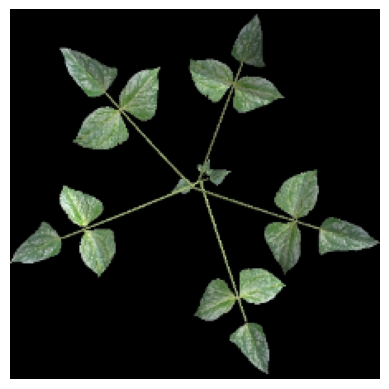

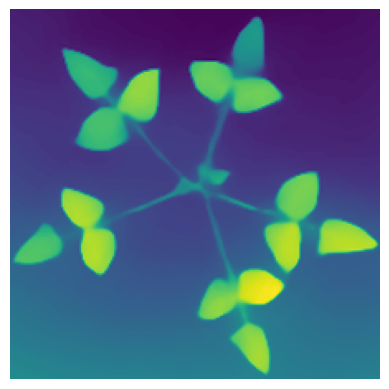

In [3]:
import cv2
img, target, depth = train_dataset[0]


rgb = img[:3]
# Normalize the RGB image to 0-255
rgb = cv2.normalize(rgb.permute(1,2,0).numpy(), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

depth = img[3:]



import matplotlib.pyplot as plt
plt.imshow(rgb)
# Axes are not needed
plt.axis('off')
plt.show()
plt.imshow(depth[0])
plt.axis('off')
plt.show()


In [4]:
from models.plightning import SimpleRegressionTest
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleRegressionTest.load_from_checkpoint("../log/20241003_CNN_TransformerRegression/version_0/checkpoints/best_epoch=76.ckpt")
model = model.to(device)
model.eval()
# model.freeze()

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


SimpleRegressionTest(
  (feature_extractor): CNN_FeatureExtractor(
    (efficientnet): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, kernel_

In [5]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(train_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:5].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)



100%|██████████| 37/37 [00:23<00:00,  1.61it/s]


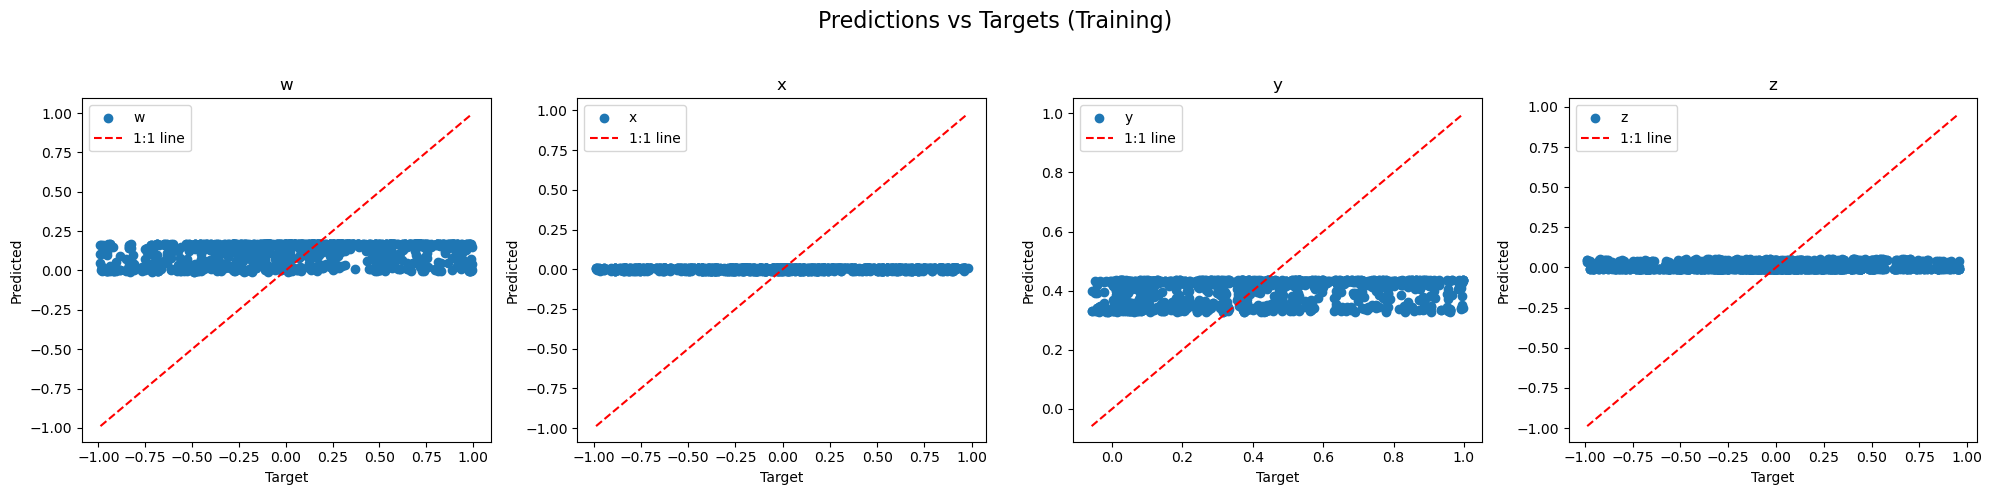

In [6]:
# Plot the predictions and targets
import matplotlib.pyplot as plt
import numpy as np

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(label)
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target, first_vec_pred, 0, "w")
plot_subplot(axes[1], first_vec_target, first_vec_pred, 1, "x")
plot_subplot(axes[2], first_vec_target, first_vec_pred, 2, "y")
plot_subplot(axes[3], first_vec_target, first_vec_pred, 3, "z")

# Add a figure title
fig.suptitle("Predictions vs Targets (Training)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

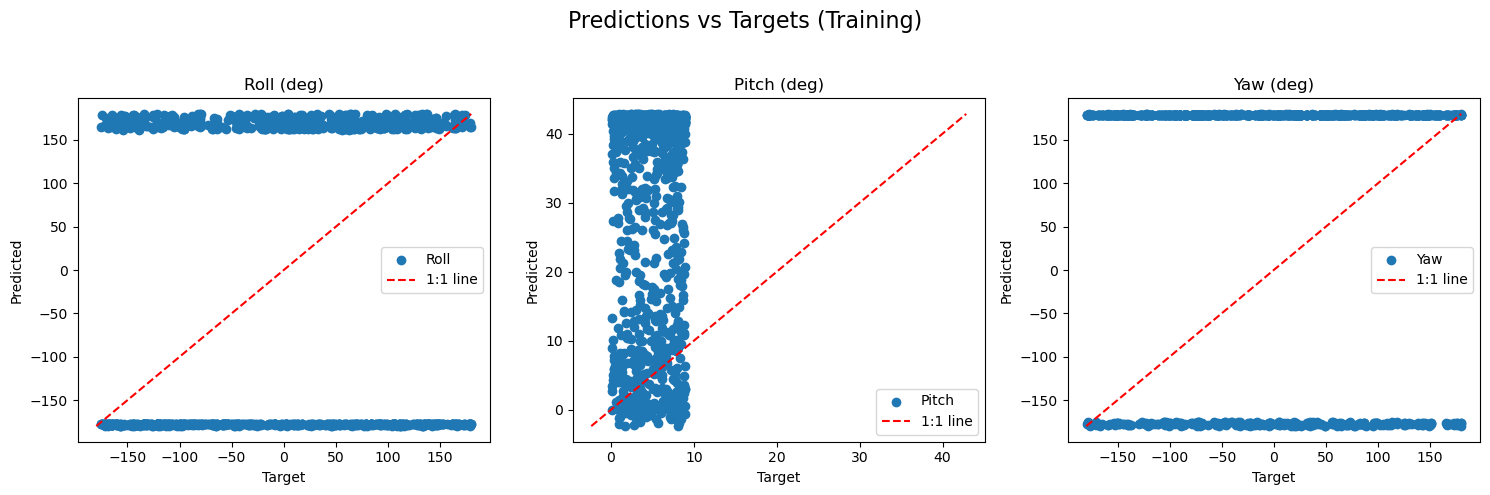

In [7]:
from utils import quaternion_to_euler
import matplotlib.pyplot as plt
import numpy as np

# Convert quaternions to Euler angles
first_vec_target_euler = np.array([quaternion_to_euler(q, degrees=True) for q in first_vec_target])
first_vec_pred_euler = np.array([quaternion_to_euler(q, degrees=True) for q in first_vec_pred])

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(f"{label} (deg)")
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target_euler, first_vec_pred_euler, 0, "Roll")
plot_subplot(axes[1], first_vec_target_euler, first_vec_pred_euler, 1, "Pitch")
plot_subplot(axes[2], first_vec_target_euler, first_vec_pred_euler, 2, "Yaw")

# Add a figure title
fig.suptitle("Predictions vs Targets (Training)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

test_dataset = PlantDataset(dataset_dir, plot=["004"], 
                            stages=["003"],
                            transform=transform, use_depth=True, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)
# Create DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(test_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:5].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)




Total 368 images and plant strings loaded


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:07<00:00,  1.71it/s]


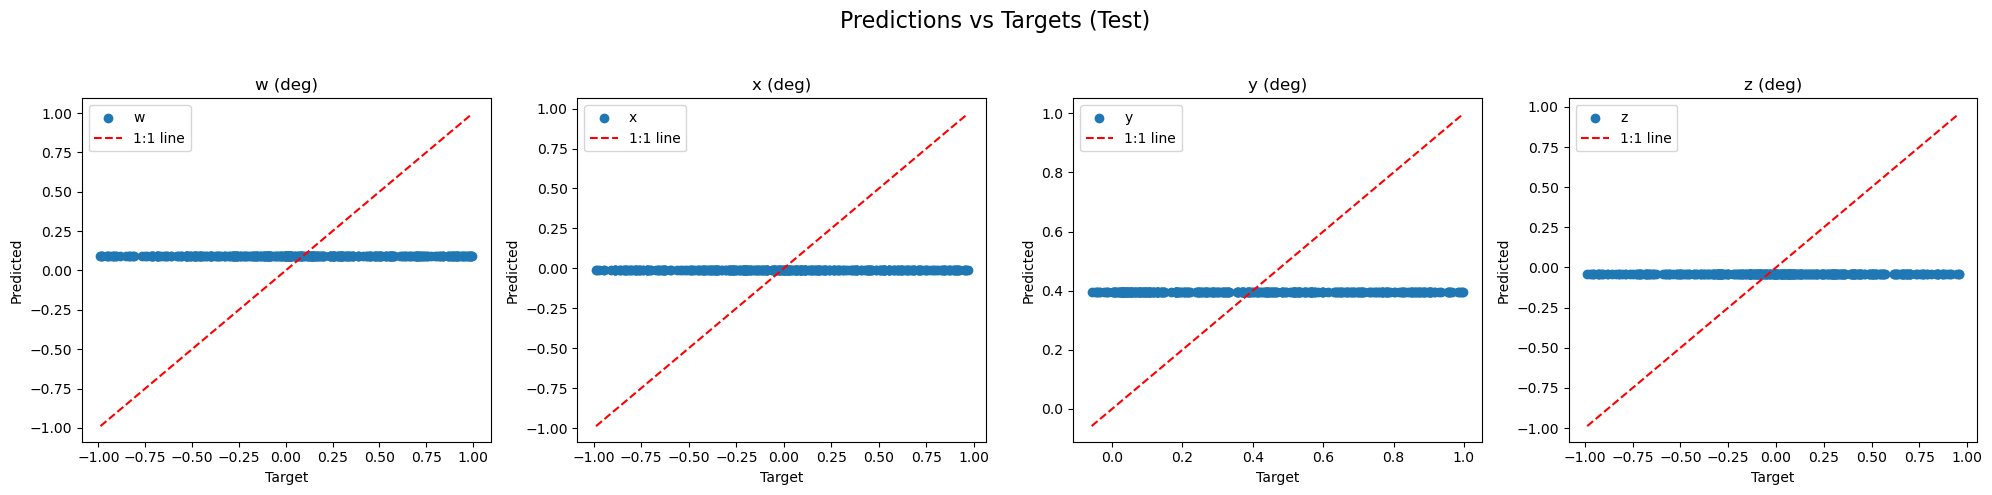

In [9]:
# Create a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target, first_vec_pred, 0, "w")
plot_subplot(axes[1], first_vec_target, first_vec_pred, 1, "x")
plot_subplot(axes[2], first_vec_target, first_vec_pred, 2, "y")
plot_subplot(axes[3], first_vec_target, first_vec_pred, 3, "z")

# Add a figure title
fig.suptitle("Predictions vs Targets (Test)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

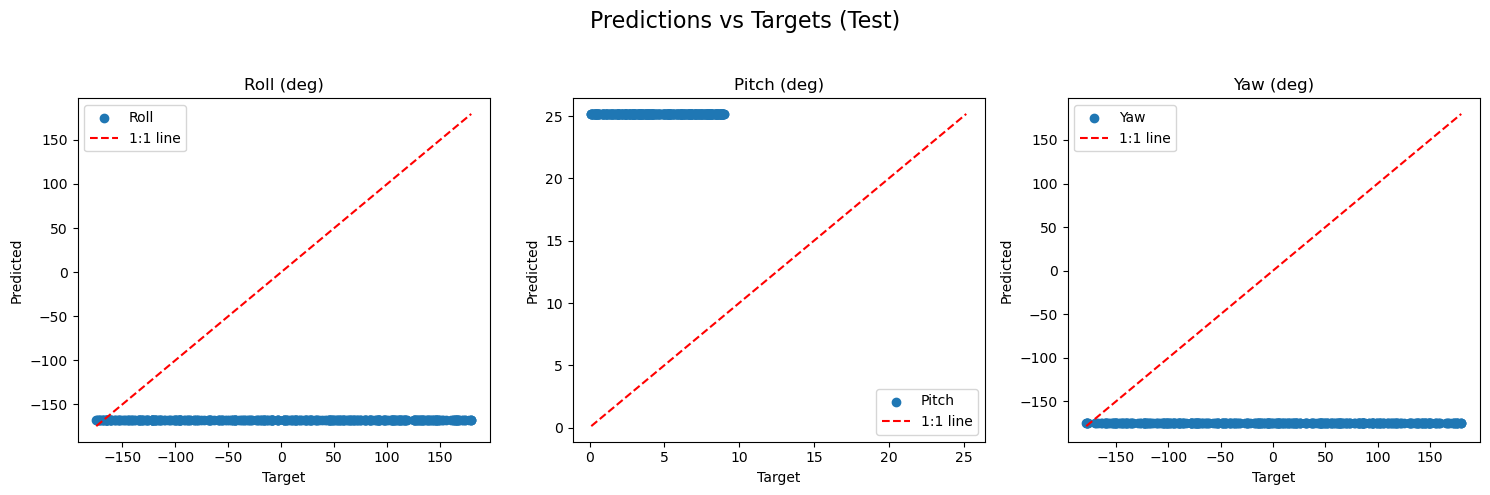

In [10]:
from utils import quaternion_to_euler
import matplotlib.pyplot as plt
import numpy as np

# Convert quaternions to Euler angles
first_vec_target_euler = np.array([quaternion_to_euler(q, degrees=True) for q in first_vec_target])
first_vec_pred_euler = np.array([quaternion_to_euler(q, degrees=True) for q in first_vec_pred])

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(f"{label} (deg)")
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target_euler, first_vec_pred_euler, 0, "Roll")
plot_subplot(axes[1], first_vec_target_euler, first_vec_pred_euler, 1, "Pitch")
plot_subplot(axes[2], first_vec_target_euler, first_vec_pred_euler, 2, "Yaw")

# Add a figure title
fig.suptitle("Predictions vs Targets (Test)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()